Import Libraries, mount google-drive and load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/train_processed.csv")

test_df = pd.read_csv("/content/drive/MyDrive/Hospital Readmission/Preprocessed Dataset/test_processed.csv")

Displaying dataset

In [ ]:
train_df.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted
0,-0.018109,-0.137206,0.797545,0.864877,0.905122,-0.788940,-1.123185,-0.290660,-0.215022,-0.506371,...,0.084008,-0.083176,-0.009343,-0.009988,-0.003531,-0.004994,-0.003531,0.927934,0.548385,2
1,-0.709643,-0.137206,0.305627,1.870193,0.041303,-0.204749,2.321763,-0.290660,-0.215022,-0.506371,...,0.084008,-0.083176,-0.009343,-0.009988,-0.003531,-0.004994,-0.003531,-1.077663,0.548385,2
2,-0.018109,-0.327077,-1.170125,-0.810650,0.041303,1.547823,-0.138914,0.483382,-0.215022,-0.506371,...,0.084008,-0.083176,-0.009343,-0.009988,-0.003531,-0.004994,-0.003531,0.927934,0.548385,1
3,-0.709643,-0.516949,0.305627,-0.475545,-0.161949,-0.788940,-0.508016,-0.290660,-0.215022,-0.506371,...,0.084008,-0.083176,-0.009343,-0.009988,-0.003531,-0.004994,-0.003531,0.927934,0.548385,2
4,0.673425,-0.137206,-1.170125,1.199982,1.718129,2.716204,3.552101,-0.290660,-0.215022,-0.506371,...,0.084008,-0.083176,-0.009343,-0.009988,-0.003531,-0.004994,-0.003531,0.927934,-1.823535,1


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80195 entries, 0 to 80194
Data columns (total 86 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   admission_type_id                80195 non-null  float64
 1   discharge_disposition_id         80195 non-null  float64
 2   admission_source_id              80195 non-null  float64
 3   time_in_hospital                 80195 non-null  float64
 4   num_lab_procedures               80195 non-null  float64
 5   num_procedures                   80195 non-null  float64
 6   num_medications                  80195 non-null  float64
 7   number_outpatient                80195 non-null  float64
 8   number_emergency                 80195 non-null  float64
 9   number_inpatient                 80195 non-null  float64
 10  diag_1                           80195 non-null  float64
 11  diag_2                           80195 non-null  float64
 12  diag_3            

In [ ]:
print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)

Training Dataset Shape : (80195, 86)
Testing Dataset Shape : (20049, 86)


Separating Features and Target

In [ ]:
X_train = train_df.drop("readmitted", axis=1)
y_train = train_df["readmitted"]

X_test = test_df.drop("readmitted", axis=1)
y_test = test_df["readmitted"]

In [ ]:
print("X_train Shape :", X_train.shape)
print("y_train Shape :", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (80195, 85)
y_train Shape : (80195,)
X_test Shape : (20049, 85)
y_test Shape : (20049,)


In [ ]:
print(y_train.value_counts())

readmitted
2    43057
1    28138
0     9000
Name: count, dtype: int64


Visualisation

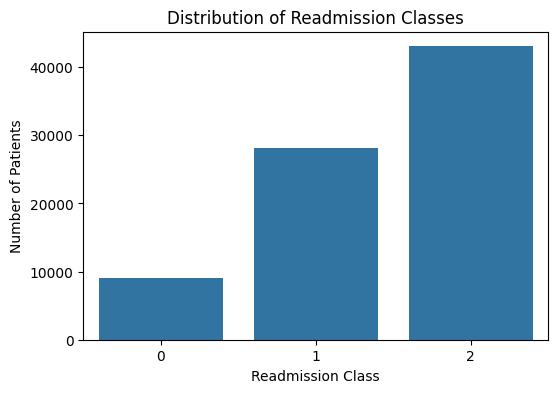

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Distribution of Readmission Classes")

plt.xlabel("Readmission Class")

plt.ylabel("Number of Patients")

plt.show()

Logistic Regression

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.567


In [ ]:
precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Precision :", round(precision,4))

Precision : 0.5258


In [ ]:
recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Recall :", round(recall,4))

Recall : 0.567


In [ ]:
f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("F1 Score :", round(f1,4))

F1 Score : 0.4963


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.35      0.01      0.02      2250
           1       0.49      0.25      0.33      7035
           2       0.58      0.89      0.71     10764

    accuracy                           0.57     20049
   macro avg       0.48      0.38      0.35     20049
weighted avg       0.53      0.57      0.50     20049



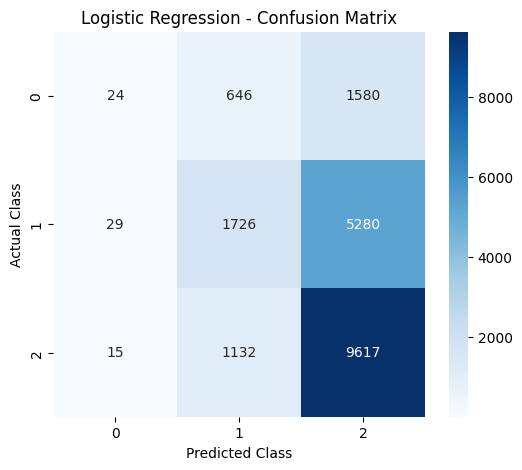

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
lr_results = (accuracy, precision, recall, f1)

Reusable Model Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained classification model and displays its performance metrics.
    """

    # Make Predictions
    y_pred = model.predict(X_test)

    # Calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Display Metrics
    print("=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

    return accuracy, precision, recall, f1

Decision Tree

Decision Tree
Accuracy : 0.4669
Precision: 0.4732
Recall   : 0.4669
F1 Score : 0.4699

Classification Report

              precision    recall  f1-score   support

           0       0.15      0.17      0.16      2250
           1       0.39      0.39      0.39      7035
           2       0.59      0.58      0.59     10764

    accuracy                           0.47     20049
   macro avg       0.38      0.38      0.38     20049
weighted avg       0.47      0.47      0.47     20049



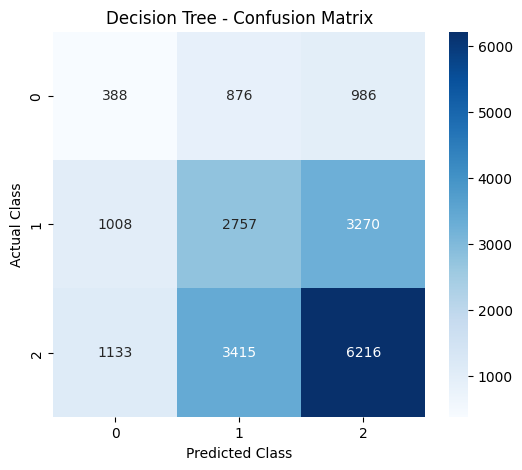

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_results = evaluate_model(
    dt,
    X_test,
    y_test,
    "Decision Tree"
)

Random Forest

Random Forest
Accuracy : 0.5783
Precision: 0.5445
Recall   : 0.5783
F1 Score : 0.5290

Classification Report

              precision    recall  f1-score   support

           0       0.40      0.01      0.03      2250
           1       0.49      0.37      0.42      7035
           2       0.61      0.83      0.70     10764

    accuracy                           0.58     20049
   macro avg       0.50      0.41      0.38     20049
weighted avg       0.54      0.58      0.53     20049



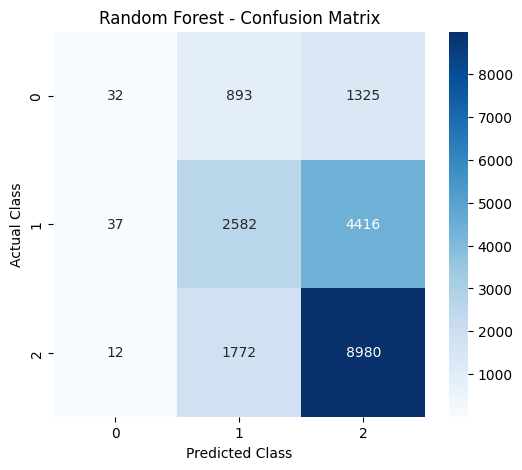

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test,
    "Random Forest"
)

KNN

K-Nearest Neighbors
Accuracy : 0.4876
Precision: 0.4730
Recall   : 0.4876
F1 Score : 0.4794

Classification Report

              precision    recall  f1-score   support

           0       0.17      0.12      0.14      2250
           1       0.39      0.40      0.40      7035
           2       0.59      0.62      0.60     10764

    accuracy                           0.49     20049
   macro avg       0.38      0.38      0.38     20049
weighted avg       0.47      0.49      0.48     20049



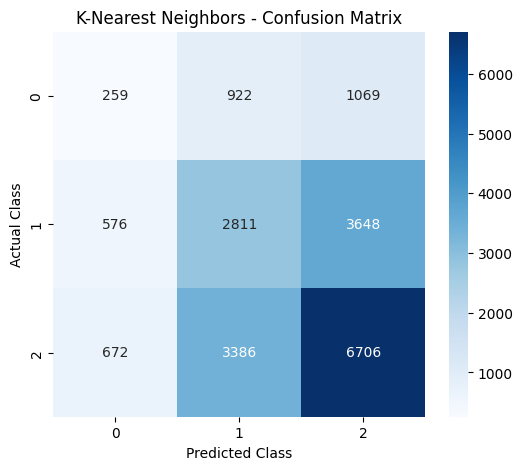

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

knn_results = evaluate_model(
    knn,
    X_test,
    y_test,
    "K-Nearest Neighbors"
)

SVM

Linear SVM
Accuracy : 0.5659
Precision: 0.4858
Recall   : 0.5659
F1 Score : 0.4850

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2250
           1       0.50      0.21      0.30      7035
           2       0.58      0.91      0.71     10764

    accuracy                           0.57     20049
   macro avg       0.36      0.38      0.34     20049
weighted avg       0.49      0.57      0.48     20049



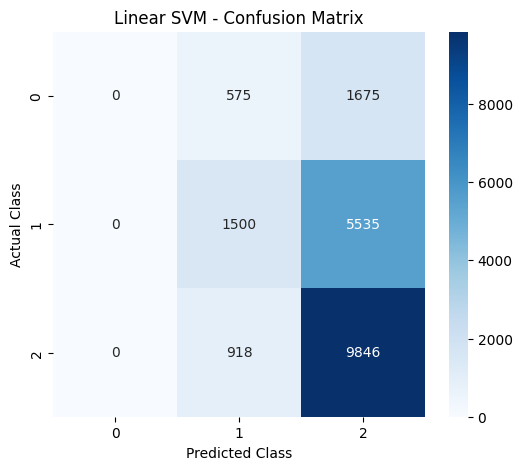

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train, y_train)

svm_results = evaluate_model(
    svm,
    X_test,
    y_test,
    "Linear SVM"
)

XG Boost

In [ ]:
print(X_train.columns.tolist())

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Male', 'gender_Unknown/Invalid', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'max_glu_serum_>300', 'max_glu_serum_None', 'max_glu_serum_Norm', 'A1Cresult_>8', 'A1Cresult_None', 'A1Cresult_Norm', 'metformin_No', 'metformin_Steady', 'metformin_Up', 'repaglinide_No', 'repaglinide_Steady', 'repaglinide_Up', 'nateglinide_No', 'nateglinide_Steady', 'nateglinide_Up', 'chlorpropamide_No', 'chlorpropamide_Steady', 'chlorpropamide_Up', 'glimepiride_No', 'glimepiride_Steady', 'glimepiride_Up', 'acetohexamide_Steady', 'glipizide_No', 'glipizide_Steady', 'glipizide_Up', 'glyburide

In [ ]:
# Rename feature columns to remove unsupported characters
X_train.columns = (
    X_train.columns
    .str.replace('[', '(', regex=False)
    .str.replace(']', ')', regex=False)
    .str.replace('<', 'LT_', regex=False)
    .str.replace('>', 'GT_', regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace('[', '(', regex=False)
    .str.replace(']', ')', regex=False)
    .str.replace('<', 'LT_', regex=False)
    .str.replace('>', 'GT_', regex=False)
)

XGBoost
Accuracy : 0.5888
Precision: 0.5611
Recall   : 0.5888
F1 Score : 0.5463

Classification Report

              precision    recall  f1-score   support

           0       0.43      0.04      0.07      2250
           1       0.51      0.40      0.45      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.52      0.42      0.41     20049
weighted avg       0.56      0.59      0.55     20049



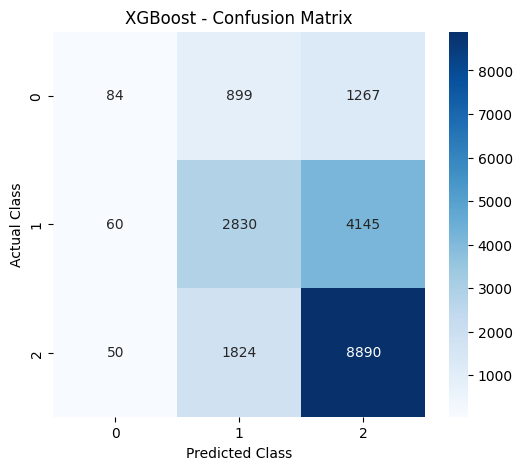

In [ ]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_results = evaluate_model(
    xgb,
    X_test,
    y_test,
    "XGBoost"
)

Model Comparision

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Linear SVM",
        "KNN",
        "XGBoost"
    ],

    "Accuracy": [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        svm_results[0],
        knn_results[0],
        xgb_results[0]
    ],

    "Precision": [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        svm_results[1],
        knn_results[1],
        xgb_results[1]
    ],

    "Recall": [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        svm_results[2],
        knn_results[2],
        xgb_results[2]
    ],

    "F1 Score": [
        lr_results[3],
        dt_results[3],
        rf_results[3],
        svm_results[3],
        knn_results[3],
        xgb_results[3]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.566961,0.525810,0.566961,0.496333
1,Decision Tree,0.466906,0.473163,0.466906,0.469912
2,Random Forest,0.578283,0.544512,0.578283,0.528972
3,Linear SVM,0.565914,0.485785,0.565914,0.484999
4,KNN,0.487605,0.473024,0.487605,0.479393
5,XGBoost,0.588758,0.561141,0.588758,0.546314


In [ ]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.588758,0.561141,0.588758,0.546314
1,Random Forest,0.578283,0.544512,0.578283,0.528972
2,Logistic Regression,0.566961,0.525810,0.566961,0.496333
3,Linear SVM,0.565914,0.485785,0.565914,0.484999
4,KNN,0.487605,0.473024,0.487605,0.479393
5,Decision Tree,0.466906,0.473163,0.466906,0.469912


Balanced Random Forest

Balanced Random Forest
Accuracy : 0.5795
Precision: 0.5523
Recall   : 0.5795
F1 Score : 0.5274

Classification Report

              precision    recall  f1-score   support

           0       0.46      0.02      0.03      2250
           1       0.50      0.35      0.41      7035
           2       0.61      0.85      0.71     10764

    accuracy                           0.58     20049
   macro avg       0.52      0.40      0.38     20049
weighted avg       0.55      0.58      0.53     20049



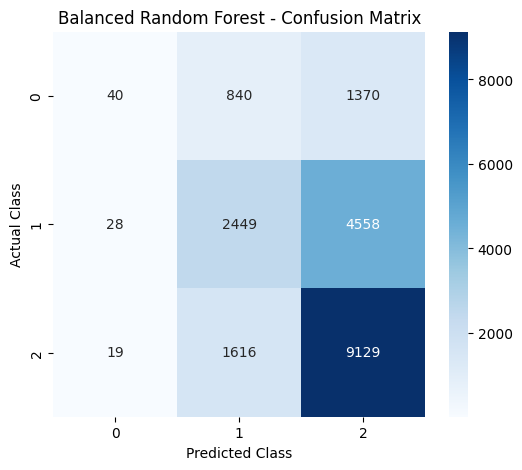

In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

rf_balanced_results = evaluate_model(
    rf_balanced,
    X_test,
    y_test,
    "Balanced Random Forest"
)

Balanced XGBoost

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [ ]:
from xgboost import XGBClassifier

xgb_balanced = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

In [ ]:
xgb_balanced.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

Balanced XGBoost
Accuracy : 0.5192
Precision: 0.5615
Recall   : 0.5192
F1 Score : 0.5350

Classification Report

              precision    recall  f1-score   support

           0       0.20      0.39      0.27      2250
           1       0.48      0.43      0.45      7035
           2       0.69      0.61      0.65     10764

    accuracy                           0.52     20049
   macro avg       0.46      0.48      0.46     20049
weighted avg       0.56      0.52      0.54     20049



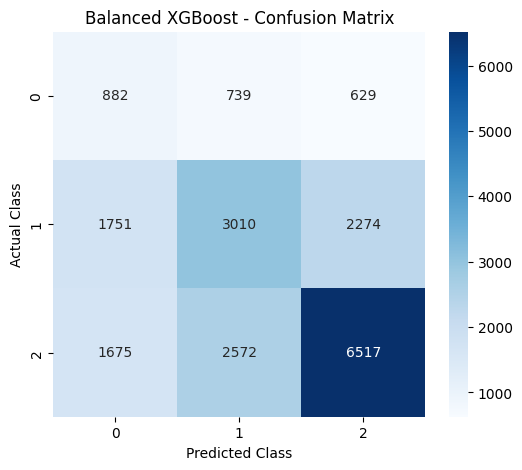

In [ ]:
xgb_balanced_results = evaluate_model(
    xgb_balanced,
    X_test,
    y_test,
    "Balanced XGBoost"
)

Tuning baseline XGBoost

Hyperparameter tuning is performed using **RandomizedSearchCV** to identify the optimal XGBoost configuration. This method efficiently searches different parameter combinations using **3-fold cross-validation**, improving model performance without exhaustively testing every possibility.



**Parameters Tuned:**
- `n_estimators`
- `max_depth`
- `learning_rate`
- `subsample`
- `colsample_bytree`
- `min_child_weight`
- `gamma`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
    "gamma": [0, 0.1]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=5,          # 👈 Only 5 random combinations
    cv=3,
    scoring="accuracy",
    random_state=42,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=3, ...),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("Best CV Accuracy:")
print(xgb_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV Accuracy:
0.5896876695342081


Tuned XGBoost
Accuracy : 0.5896
Precision: 0.5588
Recall   : 0.5896
F1 Score : 0.5444

Classification Report

              precision    recall  f1-score   support

           0       0.41      0.03      0.06      2250
           1       0.51      0.39      0.44      7035
           2       0.62      0.84      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.51      0.42      0.40     20049
weighted avg       0.56      0.59      0.54     20049



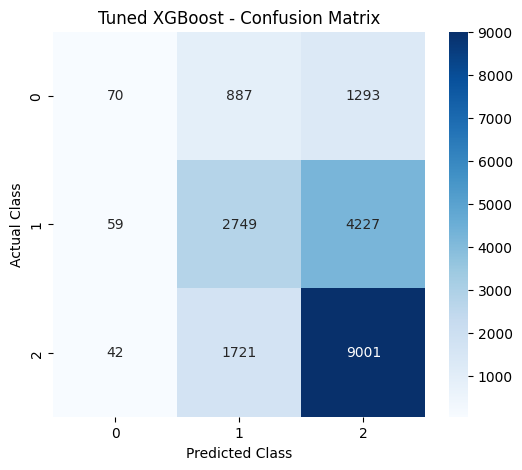

In [ ]:
best_xgb = xgb_search.best_estimator_

xgb_tuned_results = evaluate_model(
    best_xgb,
    X_test,
    y_test,
    "Tuned XGBoost"
)

CatBoost

In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=0
)

In [ ]:
cat_model.fit(X_train, y_train)

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)

CatBoost
Accuracy : 0.5872
Precision: 0.5630
Recall   : 0.5872
F1 Score : 0.5349

Classification Report

              precision    recall  f1-score   support

           0       0.49      0.02      0.03      2250
           1       0.51      0.36      0.42      7035
           2       0.61      0.86      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.54      0.41      0.39     20049
weighted avg       0.56      0.59      0.53     20049



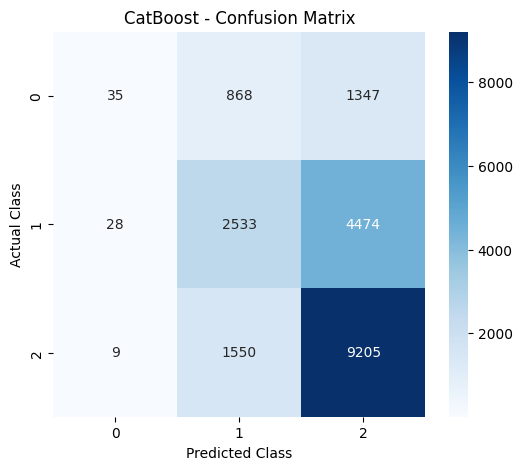

In [ ]:
cat_results = evaluate_model(
    cat_model,
    X_test,
    y_test,
    "CatBoost"
)

Rare Feature Removal (Feature Selection)

In [ ]:
# Removing extremely rare one-hot encoded features

rare_threshold = 20

rare_cols = [
    col for col in X_train.columns
    if X_train[col].nunique() <= 2 and X_train[col].sum() < rare_threshold
]

print(f"Removing {len(rare_cols)} rare features")

X_train = X_train.drop(columns=rare_cols)
X_test = X_test.drop(columns=rare_cols)

Removing 71 rare features


XG-boost after rare feature removal

In [ ]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', 'lt_', regex=False)
    .str.replace('>', 'gt_', regex=False)
)

X_test_xgb.columns = (
    X_test_xgb.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', 'lt_', regex=False)
    .str.replace('>', 'gt_', regex=False)
)

In [ ]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="mlogloss"
)

In [ ]:
# Train XGBoost
xgb.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=3, ...)

XGBoost (Feature Selection)
Accuracy : 0.5886
Precision: 0.5596
Recall   : 0.5886
F1 Score : 0.5463

Classification Report

              precision    recall  f1-score   support

           0       0.42      0.04      0.08      2250
           1       0.51      0.40      0.45      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.52      0.42      0.41     20049
weighted avg       0.56      0.59      0.55     20049



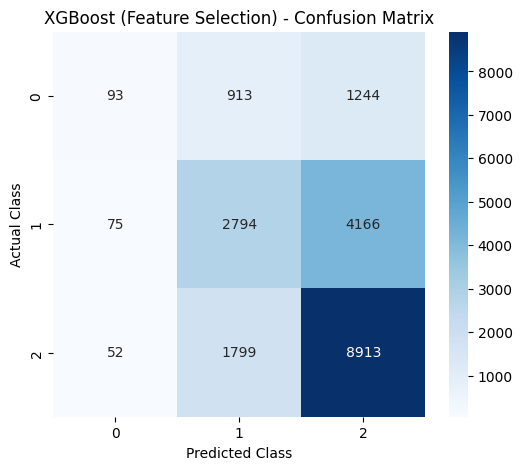

In [ ]:
xgb_results = evaluate_model(
    xgb,
    X_test_xgb,
    y_test,
    "XGBoost (Feature Selection)"
)

LightGBM

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 80195, number of used features: 14
[LightGBM] [Info] Start training from score -2.187237
[LightGBM] [Info] Start training from score -1.047340
[LightGBM] [Info] Start training from score -0.621936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
               n_estimators=500, num_class=3, objective='multiclass',
               random_state=42, subsample=0.8)

LightGBM
Accuracy : 0.5892
Precision: 0.5566
Recall   : 0.5892
F1 Score : 0.5444

Classification Report

              precision    recall  f1-score   support

           0       0.39      0.03      0.06      2250
           1       0.51      0.39      0.44      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.51      0.42      0.40     20049
weighted avg       0.56      0.59      0.54     20049



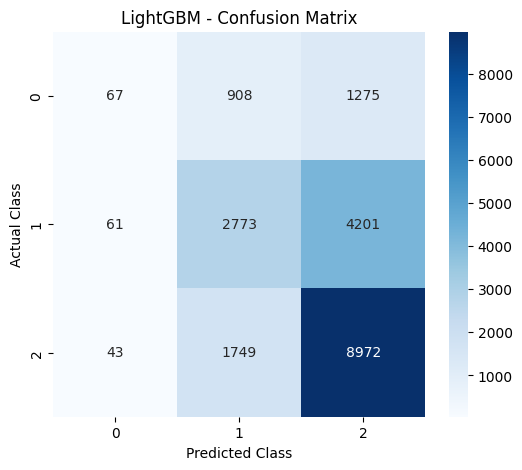

In [ ]:
lgbm_results = evaluate_model(
    lgbm,
    X_test,
    y_test,
    "LightGBM"
)

Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
et.fit(X_train, y_train)

ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)

Extra Trees
Accuracy : 0.5733
Precision: 0.5327
Recall   : 0.5733
F1 Score : 0.5300

Classification Report

              precision    recall  f1-score   support

           0       0.31      0.03      0.05      2250
           1       0.49      0.38      0.43      7035
           2       0.61      0.81      0.70     10764

    accuracy                           0.57     20049
   macro avg       0.47      0.41      0.39     20049
weighted avg       0.53      0.57      0.53     20049



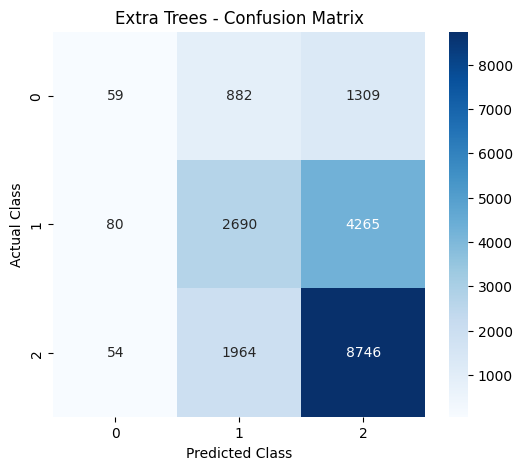

In [ ]:
et_results = evaluate_model(
    et,
    X_test,
    y_test,
    "Extra Trees"
)

Hyperparameter Tuning - LightGBM

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

In [ ]:
param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [5, 8, 10, 12, -1],
    'num_leaves': [31, 50, 70, 100],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(n_jobs=-1, num_class=3,
                                            objective='multiclass',
                                            random_state=42),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [5, 8, 10, 12, -1],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [200, 300, 500, 700,
                                                         1000],
                                        'num_leaves': [31, 50, 70, 100],
                                        'reg_alpha': [0, 0.1, 0.5, 1],
                                        'reg_lambda': [0, 0.1, 0.5, 1],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best CV Accuracy:
0.5883908117641052


In [ ]:
best_lgbm = random_search.best_estimator_

Auto-Tuned LightGBM
Accuracy : 0.5872
Precision: 0.5544
Recall   : 0.5872
F1 Score : 0.5442

Classification Report

              precision    recall  f1-score   support

           0       0.38      0.04      0.07      2250
           1       0.51      0.40      0.44      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.50      0.42      0.41     20049
weighted avg       0.55      0.59      0.54     20049



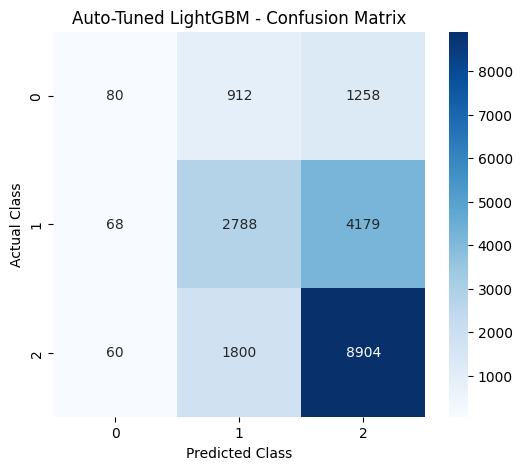

In [ ]:
lgbm_tuned_results = evaluate_model(
    best_lgbm,
    X_test,
    y_test,
    "Auto-Tuned LightGBM"
)

Optuna on LightGBM

In [ ]:
!pip install optuna lightgbm -q

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
def objective(trial):

    params = {
        "objective": "multiclass",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),

        "max_depth": trial.suggest_int("max_depth", 4, 15),

        "num_leaves": trial.suggest_int("num_leaves", 20, 150),

        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),

        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0)
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=10
)

[I 2026-07-07 18:07:29,113] A new study created in memory with name: no-name-98367d2a-96b5-4405-a030-064a7575386b
[I 2026-07-07 18:11:55,557] Trial 0 finished with value: 0.588802294407382 and parameters: {'n_estimators': 477, 'learning_rate': 0.010058890347781384, 'max_depth': 15, 'num_leaves': 79, 'min_child_samples': 39, 'subsample': 0.9110672928835365, 'colsample_bytree': 0.7073577855798591, 'reg_alpha': 1.690387480527302, 'reg_lambda': 1.853328023770661}. Best is trial 0 with value: 0.588802294407382.
[I 2026-07-07 18:15:25,571] Trial 1 finished with value: 0.5883907974312613 and parameters: {'n_estimators': 628, 'learning_rate': 0.024029571376215083, 'max_depth': 8, 'num_leaves': 22, 'min_child_samples': 26, 'subsample': 0.7541258155890103, 'colsample_bytree': 0.8386135367705725, 'reg_alpha': 1.890014495675631, 'reg_lambda': 1.8538144566505157}. Best is trial 0 with value: 0.588802294407382.
[I 2026-07-07 18:20:18,964] Trial 2 finished with value: 0.590410873495854 and parameters

In [ ]:
print("Best Accuracy:", study.best_value)

print("\nBest Parameters:\n")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best Accuracy: 0.590410873495854

Best Parameters:

n_estimators: 622
learning_rate: 0.015003407421463659
max_depth: 10
num_leaves: 66
min_child_samples: 36
subsample: 0.650693724001254
colsample_bytree: 0.6168841191263812
reg_alpha: 0.7376634656262728
reg_lambda: 0.42909631994140973


In [ ]:
best_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_jobs=-1,
    **study.best_params
)

best_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 80195, number of used features: 14
[LightGBM] [Info] Start training from score -2.187237
[LightGBM] [Info] Start training from score -1.047340
[LightGBM] [Info] Start training from score -0.621936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

LGBMClassifier(colsample_bytree=0.6168841191263812,
               learning_rate=0.015003407421463659, max_depth=10,
               min_child_samples=36, n_estimators=622, n_jobs=-1, num_class=3,
               num_leaves=66, objective='multiclass', random_state=42,
               reg_alpha=0.7376634656262728, reg_lambda=0.42909631994140973,
               subsample=0.650693724001254)

Optuna Tuned LightGBM
Accuracy : 0.5899
Precision: 0.5624
Recall   : 0.5899
F1 Score : 0.5457

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.03      0.06      2250
           1       0.51      0.40      0.45      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.52      0.42      0.41     20049
weighted avg       0.56      0.59      0.55     20049



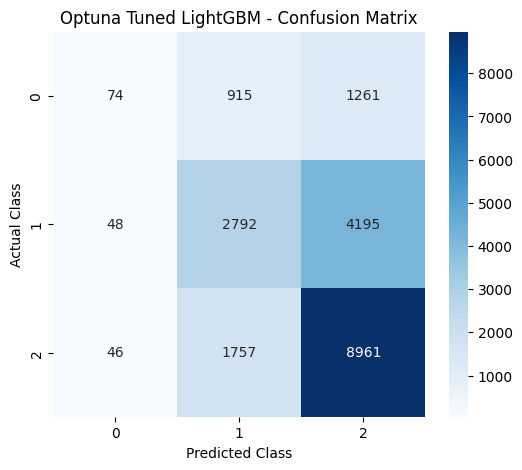

In [ ]:
lgbm_optuna_results = evaluate_model(
    best_lgbm,
    X_test,
    y_test,
    "Optuna Tuned LightGBM"
)

FLAML

In [ ]:
!pip install flaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 12.4 MB/s eta 0:00:00


In [ ]:
from flaml import AutoML
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
automl = AutoML()

In [ ]:
settings = {
    "time_budget": 900,          # 15 minutes
    "metric": "accuracy",
    "task": "classification",
    "seed": 42,
    "log_file_name": "flaml.log",
    "estimator_list": [
        "lgbm",
        "xgboost",
        "rf",
        "extra_tree",
        "xgb_limitdepth"
    ]
}

In [ ]:
automl.fit(
    X_train=X_train,
    y_train=y_train,
    **settings
)

[flaml.automl.logger: 07-07 18:49:12] {2375} INFO - task = classification
[flaml.automl.logger: 07-07 18:49:12] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 07-07 18:49:12] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 07-07 18:49:12] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf', 'extra_tree', 'xgb_limitdepth']
[flaml.automl.logger: 07-07 18:49:12] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-07 18:49:15] {3046} INFO - Estimated sufficient time budget=28608s. Estimated necessary time budget=202s.
[flaml.automl.logger: 07-07 18:49:15] {3097} INFO -  at 3.3s,	estimator lgbm's best error=4.6310e-01,	best estimator lgbm's best error=4.6310e-01
[flaml.automl.logger: 07-07 18:49:15] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-07 18:49:22] {3097} INFO -  at 10.7s,	estimator lgbm's best error=4.6310e-01,	best estimator lgbm's best error=4.6310e-01
[flaml.automl.logger: 0

In [ ]:
y_pred = automl.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("="*60)
print("FLAML AutoML")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

FLAML AutoML
Accuracy : 0.5870
Precision: 0.5585
Recall   : 0.5870
F1 Score : 0.5387

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.02      0.05      2250
           1       0.51      0.37      0.43      7035
           2       0.62      0.84      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.52      0.41      0.40     20049
weighted avg       0.56      0.59      0.54     20049



In [ ]:
print("Best Estimator:")
print(automl.best_estimator)

Best Estimator:
xgboost


In [ ]:
print("\nBest Hyperparameters:")
print(automl.best_config)


Best Hyperparameters:
{'n_estimators': 791, 'max_leaves': 6, 'min_child_weight': np.float64(4.829684974448291), 'learning_rate': np.float64(0.04133776939211417), 'subsample': np.float64(0.780390070088246), 'colsample_bylevel': np.float64(0.8809190489989699), 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.004074821343348109), 'reg_lambda': np.float64(14.647266107049909)}


FLAML XGBoost

FLAML Tuned XGBoost
Accuracy : 0.5870
Precision: 0.5586
Recall   : 0.5870
F1 Score : 0.5388

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.03      0.05      2250
           1       0.51      0.37      0.43      7035
           2       0.62      0.84      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.52      0.41      0.40     20049
weighted avg       0.56      0.59      0.54     20049



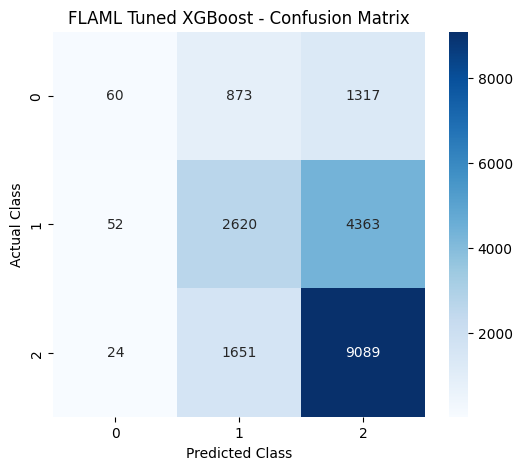

In [ ]:
from xgboost import XGBClassifier

xgb_flaml = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    # FLAML parameters
    n_estimators=791,
    learning_rate=0.04133776939211417,
    max_leaves=6,
    min_child_weight=4.829684974448291,
    subsample=0.780390070088246,
    colsample_bylevel=0.8809190489989699,
    colsample_bytree=1.0,
    reg_alpha=0.004074821343348109,
    reg_lambda=14.647266107049909,

    # Important settings
    tree_method="hist",
    random_state=42,
    eval_metric="mlogloss"
)

xgb_flaml.fit(X_train_xgb, y_train)

flaml_xgb_results = evaluate_model(
    xgb_flaml,
    X_test_xgb,
    y_test,
    "FLAML Tuned XGBoost"
)

Hybrid Model (K-Means + XGBoost)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=30,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_xgb)
test_clusters = kmeans.predict(X_test_xgb)

In [ ]:
X_train_hybrid = X_train_xgb.copy()
X_test_hybrid = X_test_xgb.copy()

X_train_hybrid["cluster"] = train_clusters
X_test_hybrid["cluster"] = test_clusters

In [ ]:
from xgboost import XGBClassifier

xgb_hybrid = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_hybrid.fit(X_train_hybrid, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=3, ...)

K-Means + XGBoost
Accuracy : 0.5879
Precision: 0.5570
Recall   : 0.5879
F1 Score : 0.5456

Classification Report

              precision    recall  f1-score   support

           0       0.40      0.04      0.07      2250
           1       0.51      0.40      0.45      7035
           2       0.62      0.83      0.71     10764

    accuracy                           0.59     20049
   macro avg       0.51      0.42      0.41     20049
weighted avg       0.56      0.59      0.55     20049



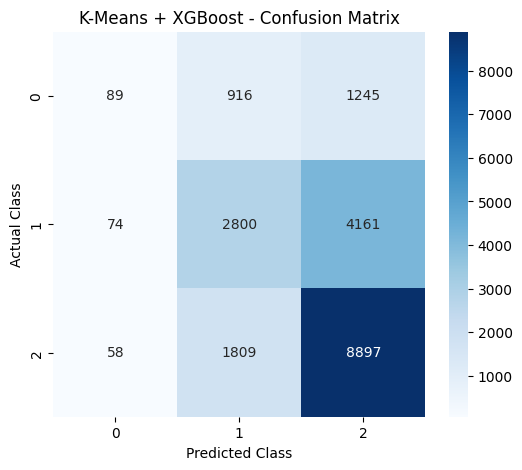

In [ ]:
hybrid_results = evaluate_model(
    xgb_hybrid,
    X_test_hybrid,
    y_test,
    "K-Means + XGBoost"
)

LightGBM Balanced

Balanced LightGBM
Accuracy : 0.5160
Precision: 0.5551
Recall   : 0.5160
F1 Score : 0.5307

Classification Report

              precision    recall  f1-score   support

           0       0.21      0.39      0.27      2250
           1       0.47      0.43      0.45      7035
           2       0.68      0.60      0.64     10764

    accuracy                           0.52     20049
   macro avg       0.45      0.47      0.45     20049
weighted avg       0.56      0.52      0.53     20049



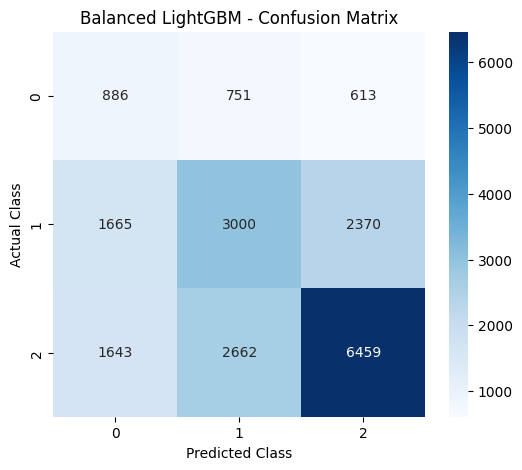

In [ ]:
from lightgbm import LGBMClassifier

lgbm_balanced = LGBMClassifier(
    objective="multiclass",
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,

    class_weight="balanced",

    random_state=42
)

lgbm_balanced.fit(X_train, y_train)

balanced_results = evaluate_model(
    lgbm_balanced,
    X_test,
    y_test,
    "Balanced LightGBM"
)

Ranking

In [ ]:
import pandas as pd

final_ranking = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5],
    "Model": [
        "K-Means + XGBoost (20 Clusters)",
        "Optuna Tuned LightGBM",
        "K-Means + XGBoost (10 Clusters)",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        0.5900,
        0.5899,
        0.5898,
        0.5888,   # Replace with your exact XGBoost accuracy if different
        0.5892
    ],
    "Weighted F1": [
        0.5478,
        0.5457,
        0.5475,
        0.5463,
        0.5444
    ]
})

print(final_ranking)

   Rank                            Model  Accuracy  Weighted F1
0     1  K-Means + XGBoost (20 Clusters)    0.5900       0.5478
1     2            Optuna Tuned LightGBM    0.5899       0.5457
2     3  K-Means + XGBoost (10 Clusters)    0.5898       0.5475
3     4                          XGBoost    0.5888       0.5463
4     5                         LightGBM    0.5892       0.5444


Saving the best models

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import joblib

project_path = "/content/drive/MyDrive/Hospital Readmission"

joblib.dump(xgb_hybrid, f"{project_path}/models/kmeans_xgboost_20.pkl")
joblib.dump(kmeans, f"{project_path}/models/kmeans_20.pkl")
joblib.dump(best_lgbm, f"{project_path}/models/optuna_tuned_lightgbm.pkl")

['/content/drive/MyDrive/Hospital Readmission/models/optuna_tuned_lightgbm.pkl']

In [ ]:
import joblib

joblib.dump(list(X_train.columns), f"{project_path}/models/feature_columns.pkl")

['/content/drive/MyDrive/Hospital Readmission/models/feature_columns.pkl']